## 15. Διανυσματικές αναπαραστάσεις

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Οι αναπαραστάσεις που βασίζονται στη συχνότητα, όπως το bag-of-words και η TF-IDF, μας επιτρέπουν να μετατρέψουμε κείμενα σε αριθμητική μορφή και να εφαρμόσουμε αλγορίθμους ανάλυσης. Ωστόσο, όπως είδαμε, οι αναπαραστάσεις αυτές έχουν σημαντικούς περιορισμούς. Αγνοούν τη σειρά των λέξεων, δεν αποτυπώνουν σημασιολογικές σχέσεις και οδηγούν σε αραιά διανύσματα πολύ υψηλής διάστασης.

Στο κεφάλαιο αυτό θα εξετάσουμε μια διαφορετική προσέγγιση: τις πυκνές διανυσματικές αναπαραστάσεις. Αντί να αντιστοιχούμε κάθε λέξη σε μία διάσταση ενός μεγάλου και αραιού χώρου, μαθαίνουμε διανύσματα μικρότερης διάστασης που αποτυπώνουν σχέσεις μεταξύ λέξεων. Με τον τρόπο αυτό, λέξεις με παρόμοια χρήση στη γλώσσα αποκτούν παρόμοιες αναπαραστάσεις.

Η προσέγγιση αυτή βασίζεται στην ιδέα ότι η σημασία μιας λέξης μπορεί να εξαχθεί από τα συμφραζόμενά της. Λέξεις που εμφανίζονται σε παρόμοια περιβάλλοντα τείνουν να έχουν παρόμοια σημασία. Σε αντίθεση με τις προηγούμενες μεθόδους, όπου οι λέξεις (ή ακολουθίες χαρακτήρων) αντιμετωπίζονται ως ανεξάρτητες μονάδες, εδώ επιχειρείται η αποτύπωση των σχέσεων μεταξύ τους.


In [ ]:
#!pip install gensim
from gensim.models import Word2Vec

# Μικρό corpus (tokenized)
sentences = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "sat", "on", "the", "rug"],
    ["the", "cat", "lay", "on", "the", "sofa"]
]

# Εκπαίδευση μοντέλου
model = Word2Vec(
    sentences,
    vector_size=50,
    window=2,
    min_count=1,
    sg=1  # skip-gram
)

In [ ]:
model.wv.most_similar("cat")

[('dog', 0.0449172779917717),
 ('mat', -0.010146031156182289),
 ('the', -0.014475265517830849),
 ('rug', -0.04407211393117905),
 ('sat', -0.15515565872192383),
 ('on', -0.17424817383289337),
 ('sofa', -0.20600517094135284),
 ('lay', -0.2091004103422165)]

In [ ]:
model.wv.similarity("cat", "dog")

np.float32(0.044917308)

In [ ]:
model.wv["elephant"]

KeyError: "Key 'elephant' not present"

### fastText

In [ ]:
from gensim.models import FastText

sentences = [
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "sat", "on", "the", "rug"],
    ["the", "cat", "lay", "on", "the", "sofa"]
]

model = FastText(
    sentences,
    vector_size=50,
    window=2,
    min_count=1
)

In [ ]:
model.wv.most_similar("cat")

[('rug', 0.2372078150510788),
 ('mat', 0.06545684486627579),
 ('sat', 0.04096408933401108),
 ('the', -0.018225930631160736),
 ('on', -0.06860970705747604),
 ('dog', -0.10638609528541565),
 ('lay', -0.14624156057834625),
 ('sofa', -0.23050545156002045)]

In [ ]:
model.wv["cats"]

array([-2.5676787e-03, -2.8748128e-03,  2.5494560e-03, -6.4890236e-03,
        4.3736072e-03, -1.7640220e-03, -8.7232889e-05, -5.5866304e-04,
        1.9833671e-03,  1.4630699e-03,  5.1124213e-04, -1.0078826e-02,
       -1.0413463e-02,  3.3614468e-03,  1.6281906e-03, -3.3903443e-03,
       -1.9692704e-03, -7.1176738e-03, -5.1779235e-03, -1.1152256e-03,
        2.7892119e-03, -1.9370187e-03,  4.1785119e-03, -3.4944937e-03,
       -5.7107648e-03, -9.4580835e-05,  6.1908736e-06,  1.7229036e-03,
       -3.8311225e-03,  1.8480814e-03, -1.1468232e-03,  2.2992431e-03,
       -5.8533699e-04,  3.2667353e-04, -2.9543788e-05, -3.9652633e-03,
        7.0395223e-03, -3.5507090e-03, -6.4643761e-03, -6.2566833e-03,
        8.2285432e-03,  3.2371283e-03,  4.2970092e-03, -4.2849937e-03,
        4.2458501e-04,  1.5493539e-03, -5.1091108e-03, -2.0315067e-04,
        1.7533153e-03,  9.3974220e-04], dtype=float32)

In [ ]:
model.wv.most_similar("cats")

[('cat', 0.4626122713088989),
 ('rug', 0.20202907919883728),
 ('on', 0.18321676552295685),
 ('sat', 0.0756167471408844),
 ('the', 0.053796712309122086),
 ('lay', 0.016714004799723625),
 ('dog', 0.0010941282380372286),
 ('sofa', -0.17246867716312408),
 ('mat', -0.18347658216953278)]

#### Αναλογίες

In [ ]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
model.similarity("king", "queen")

np.float32(0.6510957)

In [ ]:
model.most_similar("king")

[('kings', 0.7138045430183411),
 ('queen', 0.6510956883430481),
 ('monarch', 0.6413194537162781),
 ('crown_prince', 0.6204220056533813),
 ('prince', 0.6159993410110474),
 ('sultan', 0.5864824056625366),
 ('ruler', 0.5797567367553711),
 ('princes', 0.5646552443504333),
 ('Prince_Paras', 0.5432944297790527),
 ('throne', 0.5422105193138123)]

In [ ]:
model.most_similar(positive=["king", "woman"], negative=["man"])

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581),
 ('kings', 0.5236844420433044),
 ('Queen_Consort', 0.5235945582389832),
 ('queens', 0.518113374710083),
 ('sultan', 0.5098593235015869),
 ('monarchy', 0.5087411403656006)]

In [ ]:
import numpy as np

def sentence_embedding(sentence):
    words = sentence.split()
    vectors = [model[w] for w in words if w in model]
    return np.mean(vectors, axis=0)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

s1 = sentence_embedding("the cat sat on the mat")
s2 = sentence_embedding("the dog sat on the rug")

cosine_similarity(s1.reshape(1, -1), s2.reshape(1, -1))

array([[0.8301155]], dtype=float32)

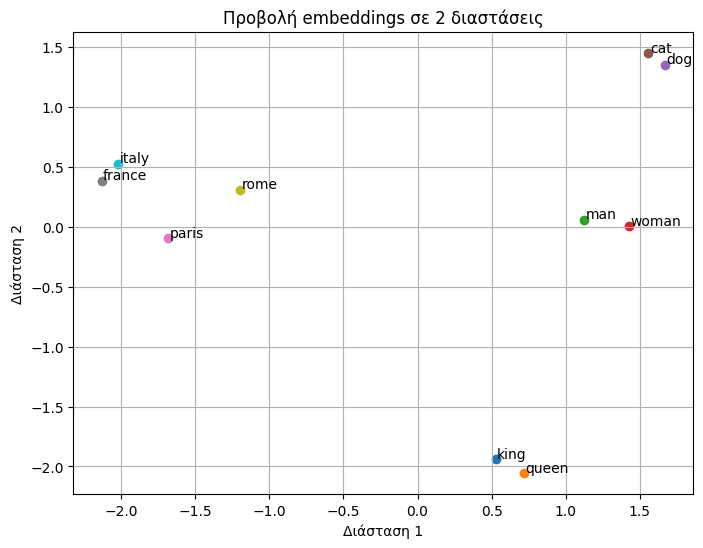

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = [
    "king", "queen", "man", "woman",
    "dog", "cat",
    "paris", "france", "rome", "italy"
]

vectors = [model[w] for w in words]

# Μείωση διάστασης σε 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8, 6))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Προβολή embeddings σε 2 διαστάσεις")
plt.xlabel("Διάσταση 1")
plt.ylabel("Διάσταση 2")

plt.grid()
plt.show()

### 15.5 Εφαρμογή: Σημασιολογική ομοιότητα παροιμιών

In [ ]:
tokenized = [text.lower().split() for text in data.text]

In [ ]:
from gensim.models import FastText

model = FastText(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2
)

In [ ]:
import numpy as np

def sentence_embedding(tokens, model):
    vectors = [model.wv[w] for w in tokens]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

sentence_vectors = np.vstack([
    sentence_embedding(tokens, model)
    for tokens in tokenized
])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(sentence_vectors)

query_idx = 0
similar_indices = sim_matrix[query_idx].argsort()[::-1][1:6]

In [ ]:
print("Αρχική παροιμία:")
print(data.text.iloc[query_idx])
print()

print("Παρόμοιες παροιμίες:")
for i in similar_indices:
    print("-", data.text.iloc[i])

Αρχική παροιμία:
Γέλια σαν κομπολόγια

Παρόμοιες παροιμίες:
- Μαύρα μάτια σαν ελιές και γεμάτα μαργιολιές
- Μαλώνουν σαν τα προγόνια
- Σαν νάρκετουν κουρσάριν
- Σαν τα σπίτια της Πεπέλης
- Κατακαϊμένε άνθρωπε σαν πόντικας γεννιέσαι, σαν λοντάρι θρέφεσαι, σαν τη δροσιά χαλειέσαι
